In [2]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

In [35]:
#read csv
df=pd.read_csv(r"E:\Priya python and data science\Data Analysis\Capstone project\Financial fraud\cc_data.csv")
df

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,1286992,17-06-2020 04:58,30546453310167,fraud_Jakubowski Group,food_dining,55.43,Nicholas,Tran,M,672 Randall Burg Suite 551,...,43.4512,-71.4890,7430,"Scientist, research (medical)",13-01-1955,b7d8dd8e9f941f316e5af3426dce91c0,1371445103,43.573310,-71.975075,0
388998,329380,06-06-2019 05:52,3562264947797240,fraud_Lockman Ltd,grocery_pos,111.77,Anthony,Velasquez,M,609 Hunt Grove,...,37.6047,-85.4251,301,"Research officer, political party",17-03-1967,6226318c59455a8a56dadf44307031b6,1338961944,38.538512,-84.999516,0
388999,950878,16-01-2020 13:20,4099707841315750,"fraud_Nicolas, Hills and McGlynn",entertainment,52.98,James,Stephens,M,1166 Castillo Mountains,...,38.2586,-78.4074,9815,"Designer, ceramics/pottery",07-07-1975,81287d23caeb5a07d0dd9ff7d61ddd9c,1358342419,38.423962,-78.882504,0
389000,958274,20-01-2020 08:51,676118385837,"fraud_Reichert, Huels and Hoppe",shopping_net,3.38,Katelyn,Wise,F,674 Maureen Summit Apt. 276,...,44.9897,-122.6187,1252,"Engineer, petroleum",06-02-1937,b78283119c244578ee42b7f0f7708496,1358671894,45.180731,-122.515971,0


In [4]:
df.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [36]:
#checking dimensions of dataset
df.shape

(389002, 23)

In [37]:
#data type and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  int64  
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [38]:
#How many unique values are there in each categorical variable?
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    print(col,":",df[col].nunique())
    

trans_date_trans_time : 293627
merchant : 693
category : 14
first : 352
last : 481
gender : 2
street : 979
city : 890
state : 51
job : 492
dob : 964
trans_num : 389002


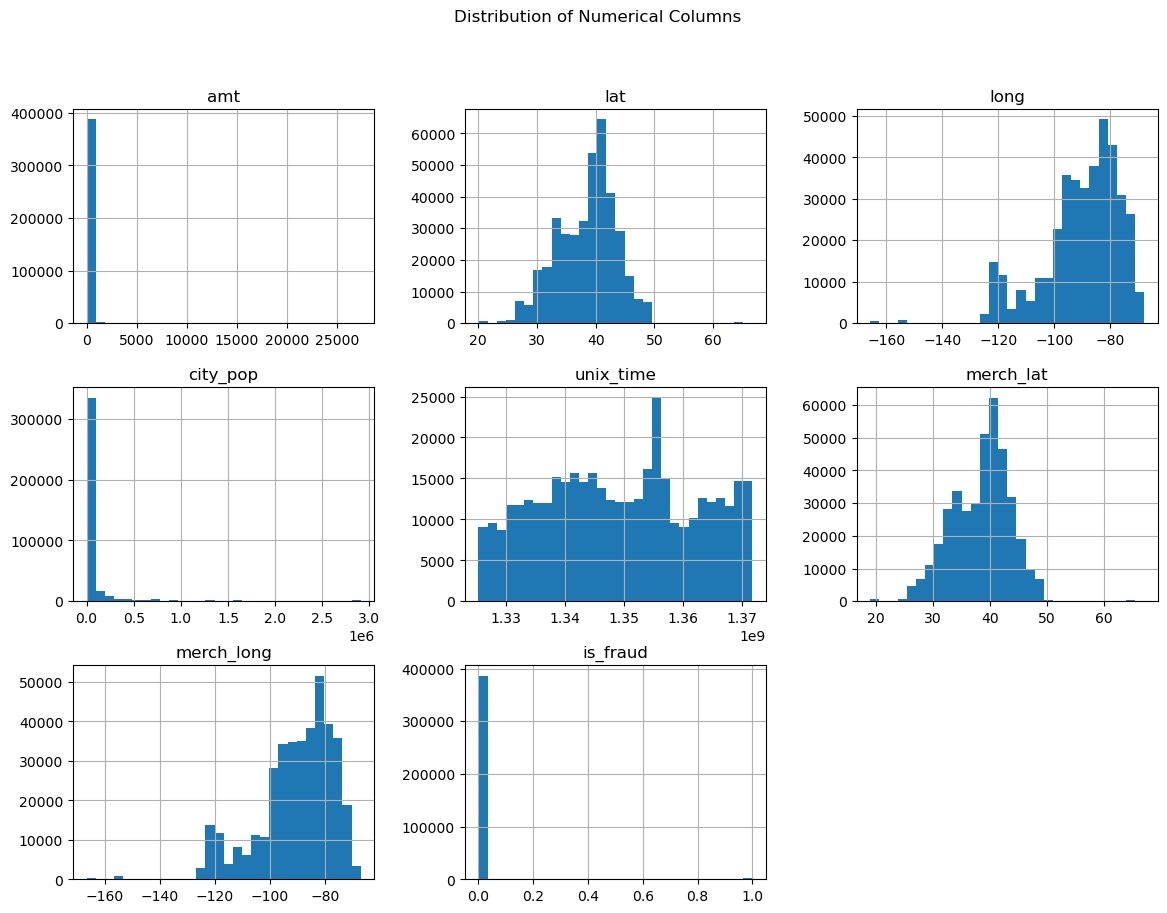

In [40]:
#What is the distribution of numerical variables in the dataset?
num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['index','zip','cc_num']).columns
df[num_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Distribution of Numerical Columns")
plt.show()

In [41]:
#Are there any missing values in the dataset? If so, how should they be handled?
df.isnull().sum()

index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [42]:
#What are the summary statistics (mean, median, min, max, etc.) for numerical variables?
df[num_cols].describe()

,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,70.442148,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,162.203915,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,9.660000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,47.570000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,83.077500,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,27390.120000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [43]:
#Is there any correlation between numerical variables? If so, how strong is the correlation?
corr_matrix=df[['amt','city_pop','is_fraud']]
correl=corr_matrix.corr()

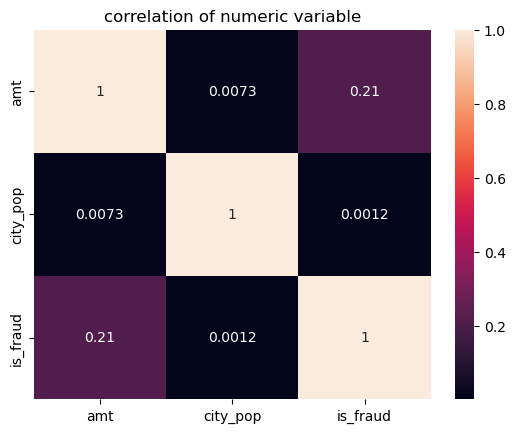

In [44]:
sns.heatmap(correl,annot=True)
plt.title("correlation of numeric variable")
plt.show()
          

<function matplotlib.pyplot.show(close=None, block=None)>

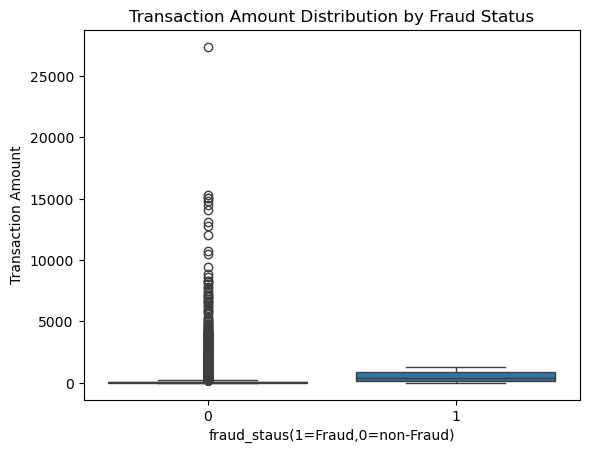

In [45]:
#How does the distribution of an amt differ across is_fraud categories?
df['is_fraud'].value_counts
sns.boxplot(x='is_fraud',y='amt',data=df)
plt.xlabel("fraud_staus(1=Fraud,0=non-Fraud)")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount Distribution by Fraud Status")
plt.show

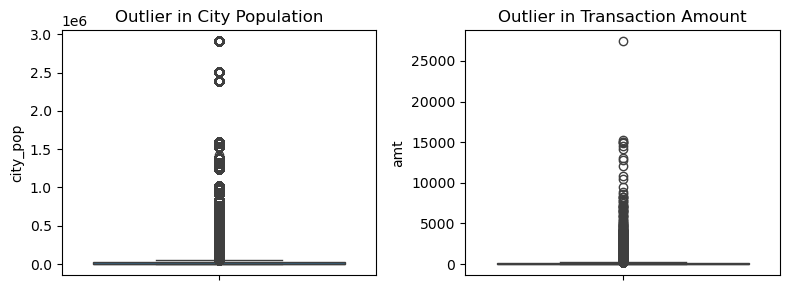

In [46]:
#Are there any outliers in the city_pop and amt?

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
sns.boxplot(data=df, y='city_pop')
plt.title("Outlier in City Population")
plt.subplot(1,2,2)
sns.boxplot(data=df, y='amt')
plt.title("Outlier in Transaction Amount")
plt.tight_layout()
plt.show()

C:\Users\PRADIP\AppData\Local\Temp\ipykernel_5616\1043142588.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])


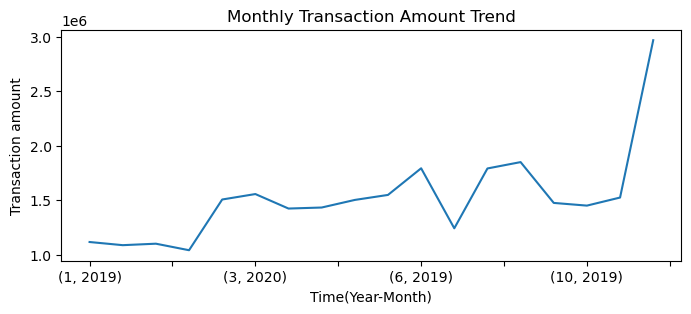

In [48]:
#Are there any trends or patterns in the data over time (if applicable)?
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])
df['Month']=df['trans_date_trans_time'].dt.month
df['Year']=df['trans_date_trans_time'].dt.year
df['Day of week']=df['trans_date_trans_time'].dt.day_name()
df['hour'] = df['trans_date_trans_time'].dt.hour

#Monthly Transaction Amount Trend
monthly_trend=df.groupby(['Month','Year'])['amt'].sum()
monthly_trend.plot(figsize=(8,3))
plt.xlabel('Time(Year-Month)')
plt.ylabel('Transaction amount')
plt.title('Monthly Transaction Amount Trend')
plt.show()



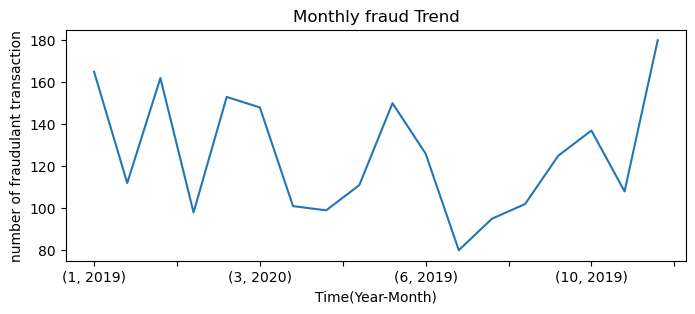

In [49]:
#Monthly fraud Trend
monthly_trend=df.groupby(['Month','Year'])['is_fraud'].sum()
monthly_trend.plot(figsize=(8,3))
plt.xlabel('Time(Year-Month)')
plt.ylabel('number of fraudulant transaction')
plt.title('Monthly fraud Trend')
plt.show()


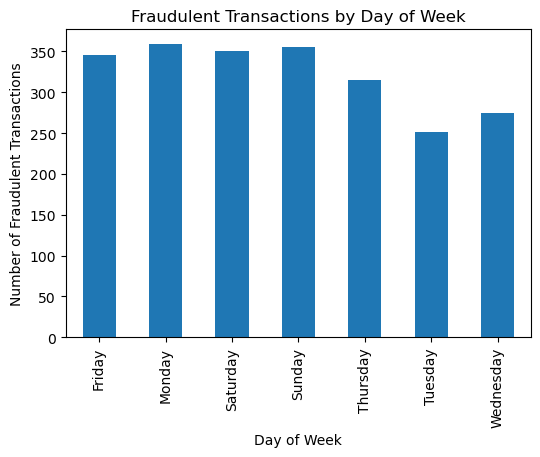

In [50]:
#Fraud by Day of Week
fraud_by_day = df.groupby('Day of week')['is_fraud'].sum()
fraud_by_day.plot(kind='bar', figsize=(6,4))
plt.xlabel("Day of Week")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Fraudulent Transactions by Day of Week")
plt.show()

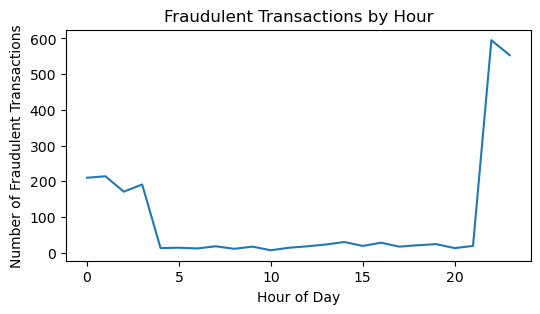

In [51]:
#Fraud by Hour of Day
fraud_by_hour = df.groupby('hour')['is_fraud'].sum()
fraud_by_hour.plot(kind='line', figsize=(6,3))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Fraudulent Transactions by Hour")
plt.show()

In [52]:
#Are there any unusual or unexpected values in the dataset that require further investigation?
df[df['amt'] <= 0]
df[df['city_pop'] <= 0]
df.sort_values(by='amt', ascending=False).head(10)
df['is_fraud'].unique()

array([0, 1])

In [112]:
#Are there any potential data entry errors or inconsistencies in the dataset?
#Check Fraud Label Consistency
df['is_fraud'].value_counts()

is_fraud
0    386750
1      2252
Name: count, dtype: int64

In [113]:
# Date & Time Consistency
df['trans_date_trans_time'].min(), df['trans_date_trans_time'].max()

(Timestamp('2019-01-01 00:06:00'), Timestamp('2020-06-21 12:13:00'))

In [54]:
#Check Categorical Consistency
df['gender'].value_counts()
df['category'].value_counts()
df['state'].value_counts()

state
TX    28482
NY    25034
PA    23911
CA    17007
OH    13933
MI    13824
FL    12896
IL    12863
AL    12321
MO    11526
MN     9665
AR     9338
NC     9115
WI     8923
VA     8891
SC     8763
KY     8601
IN     8200
IA     8101
OK     7924
GA     7912
MD     7853
WV     7583
NJ     7359
NE     7238
KS     6858
MS     6386
LA     6293
WY     5767
WA     5718
OR     5590
TN     5211
NM     4915
ME     4795
ND     4407
CO     4110
SD     3791
MA     3718
MT     3533
VT     3508
AZ     3243
UT     3137
NH     2404
CT     2380
ID     1710
NV     1678
DC     1061
HI      757
AK      597
RI      171
DE        1
Name: count, dtype: int64

In [15]:
#What are the top factors that influence the target variable, if applicable?
#Correlation with Target Variable
df.select_dtypes(include='number').corr()['is_fraud'].sort_values(ascending=False)


is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
index        -0.006121
unix_time    -0.006562
Name: is_fraud, dtype: float64

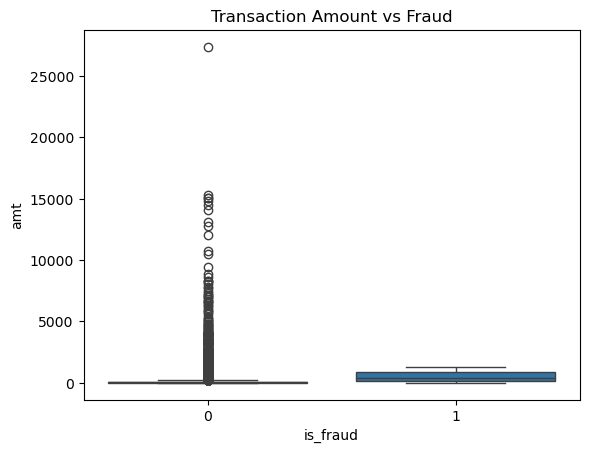

In [17]:
#Transaction Amount vs Fraud
sns.boxplot(data=df,x='is_fraud',y='amt')
plt.title("Transaction Amount vs Fraud")
plt.show()

In [20]:
#Category-wise Fraud Rate
df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(10)

category
shopping_net     0.016317
misc_net         0.015017
grocery_pos      0.014090
shopping_pos     0.007226
gas_transport    0.004870
travel           0.003445
misc_pos         0.003202
grocery_net      0.002889
personal_care    0.002776
entertainment    0.002418
Name: is_fraud, dtype: float64

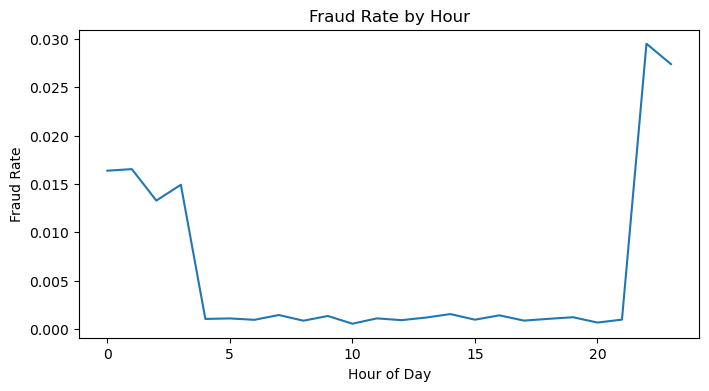

In [57]:
#Time-Based Influence
df.groupby('hour')['is_fraud'].mean().plot(
    kind='line', figsize=(8,4), title='Fraud Rate by Hour'
)
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.show()


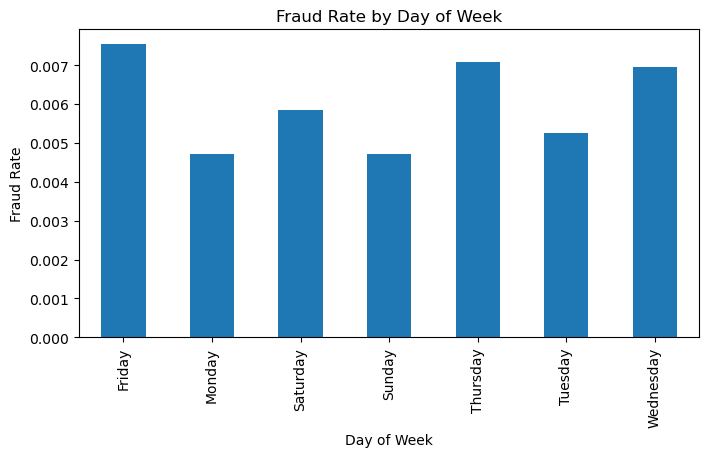

In [59]:
df.groupby('Day of week')['is_fraud'].mean().plot(
    kind='bar', figsize=(8,4), title='Fraud Rate by Day of Week'
)
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate')
plt.show()